# PICASO Tint-sensitivity partial analysis

## tl;dr

- This frozen snapshot contains **26/36 valid NetCDF models**: both 255 K cases are complete (12 each), while the 500 K case has only two clear, Tint=25 K models.
- Across converged endpoint pairs in the complete 255 K cases, changing Tint from 25 to 100 K changes transmission spectra by only **1.6–9.3 ppm RMS**. Metallicity, clouds, gravity, and Teq have larger effects in the current sample.
- Seven saved models have `climate_converged=false`; they are finite and restartable but remain provisional. Thermal planet/star ratios are excluded because a dimensional inconsistency was found in the installed PICASO climate stellar-flux path.

## Context & Methods

This is a technical, frozen-snapshot companion to the partial-results report. The unit of analysis is one unique case × Tint × cloud × metallicity model. Transmission modulation is peak-to-trough transit depth over 0.6–15 µm, in ppm. Tint sensitivity is the wavelength-wise RMS difference between Tint=100 K and Tint=25 K spectra for otherwise identical models.

### Key Assumptions

- Only the explicit file list below is analyzed, so ongoing Slurm tasks cannot change denominators.
- `climate_converged=false` is not treated as a file failure, but claims depending on such models are flagged provisional.
- Thermal ratios are retained in the source files but excluded from scientific comparisons pending correction and rerun.

In [1]:
from pathlib import Path
import json
import re
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

ROOT = Path('/home/u11/danielxinhuang/Documents/aurora')
OUT = Path('/home/u11/danielxinhuang/Documents/aurora/analysis/tint_sensitivity_partial_20260721')
OUTPUT_DIR = ROOT / "outputs" / "tint_sensitivity_36"
LOG_DIR = ROOT / "logs" / "tint_sensitivity_36"
SNAPSHOT_UTC = "2026-07-21T17:21:30Z"
SNAPSHOT_FILES = ['00_k2_18b_observed_tint025_cloud_free_mh001x.nc', '01_k2_18b_observed_tint025_cloud_free_mh100x.nc', '02_k2_18b_observed_tint025_fully_cloudy_virga_mh001x.nc', '03_k2_18b_observed_tint025_fully_cloudy_virga_mh100x.nc', '04_k2_18b_observed_tint050_cloud_free_mh001x.nc', '05_k2_18b_observed_tint050_cloud_free_mh100x.nc', '06_k2_18b_observed_tint050_fully_cloudy_virga_mh001x.nc', '07_k2_18b_observed_tint050_fully_cloudy_virga_mh100x.nc', '08_k2_18b_observed_tint100_cloud_free_mh001x.nc', '09_k2_18b_observed_tint100_cloud_free_mh100x.nc', '10_k2_18b_observed_tint100_fully_cloudy_virga_mh001x.nc', '11_k2_18b_observed_tint100_fully_cloudy_virga_mh100x.nc', '12_gj_1214b_low_tint025_cloud_free_mh001x.nc', '13_gj_1214b_low_tint025_cloud_free_mh100x.nc', '14_gj_1214b_low_tint025_fully_cloudy_virga_mh001x.nc', '15_gj_1214b_low_tint025_fully_cloudy_virga_mh100x.nc', '16_gj_1214b_low_tint050_cloud_free_mh001x.nc', '17_gj_1214b_low_tint050_cloud_free_mh100x.nc', '18_gj_1214b_low_tint050_fully_cloudy_virga_mh001x.nc', '19_gj_1214b_low_tint050_fully_cloudy_virga_mh100x.nc', '20_gj_1214b_low_tint100_cloud_free_mh001x.nc', '21_gj_1214b_low_tint100_cloud_free_mh100x.nc', '22_gj_1214b_low_tint100_fully_cloudy_virga_mh001x.nc', '23_gj_1214b_low_tint100_fully_cloudy_virga_mh100x.nc', '24_gj_1214b_observed_tint025_cloud_free_mh001x.nc', '25_gj_1214b_observed_tint025_cloud_free_mh100x.nc']
paths = [OUTPUT_DIR / name for name in SNAPSHOT_FILES]
assert len(paths) == 26 and all(path.is_file() for path in paths)

## Data

### 1. Load and profile the frozen NetCDF cohort

In [2]:
rows = []
spectra = {}
for path in paths:
    with xr.open_dataset(path) as ds:
        ds.load()
        wave = ds.wavelength_um.values.astype(float)
        transmission = ds.transmission_depth.values.astype(float)
        albedo = ds.geometric_albedo.values.astype(float)
        pressure = ds.pressure_bar.values.astype(float)
        temperature = ds.temperature_k.values.astype(float)
        run_id = ds.attrs["run_id"]
        case_id = run_id.split("_tint")[0].split("_", 1)[1]
        cloud = "cloudy" if float(ds.cloud_fraction.item()) == 1.0 else "clear"

        assert np.all(np.isfinite(transmission))
        assert np.all(np.isfinite(albedo))
        assert np.all(ds.kzz_cm2_s_profile.values == 1e10)
        assert int(ds.quench_enabled.item()) == int(ds.quench_applied.item()) == 1
        assert int(ds.diseq_chem.item()) == 1
        assert int(ds.self_consistent_kzz.item()) == 0

        rows.append({
            "run_index": int(ds.run_index.item()),
            "run_id": run_id,
            "case_id": case_id,
            "tint_k": float(ds.tint_k.item()),
            "metallicity_xsolar": float(ds.metallicity_xsolar.item()),
            "cloud": cloud,
            "climate_converged": bool(ds.climate_converged.item()),
            "transmission_modulation_ppm": float(np.ptp(transmission) * 1e6),
            "visible_albedo_median": float(np.median(albedo[(wave >= 0.6) & (wave <= 1.0)])),
            "temperature_1bar_k": float(np.interp(0.0, np.log10(pressure), temperature)),
            "max_quench_difference_dex": float(ds.max_quench_log10_difference.item()),
            "pressure_levels": int(pressure.size),
            "pressure_max_bar": float(pressure.max()),
            "runtime_seconds": float(ds.runtime_seconds.item()),
        })
        spectra[int(ds.run_index.item())] = transmission

models = pd.DataFrame(rows).sort_values("run_index").reset_index(drop=True)
models.to_csv(OUT / "model_summary.csv", index=False)
models.head(10)

,run_index,run_id,case_id,tint_k,metallicity_xsolar,cloud,climate_converged,transmission_modulation_ppm,visible_albedo_median,temperature_1bar_k,max_quench_difference_dex,pressure_levels,pressure_max_bar,runtime_seconds
0,0,00_k2_18b_observed_tint025_cloud_free_mh001x,k2_18b_observed,25.0,1.0,clear,True,154.100531,0.072584,369.147499,42.582928,61,31.622777,426.599541
1,1,01_k2_18b_observed_tint025_cloud_free_mh100x,k2_18b_observed,25.0,100.0,clear,True,123.884311,0.004426,569.118883,39.410466,61,31.622777,710.844161
2,2,02_k2_18b_observed_tint025_fully_cloudy_virga_...,k2_18b_observed,25.0,1.0,cloudy,False,154.089565,0.072588,368.948973,42.580311,61,31.622777,903.011454
3,3,03_k2_18b_observed_tint025_fully_cloudy_virga_...,k2_18b_observed,25.0,100.0,cloudy,True,76.472757,0.177034,517.160600,38.284737,61,31.622777,1435.811533
4,4,04_k2_18b_observed_tint050_cloud_free_mh001x,k2_18b_observed,50.0,1.0,clear,True,154.127646,0.072566,369.451590,42.606571,61,31.622777,424.185352
5,5,05_k2_18b_observed_tint050_cloud_free_mh100x,k2_18b_observed,50.0,100.0,clear,True,123.532240,0.004375,572.714275,39.445531,61,31.622777,760.032714
6,6,06_k2_18b_observed_tint050_fully_cloudy_virga_...,k2_18b_observed,50.0,1.0,cloudy,False,154.116833,0.072570,369.255722,42.604018,61,31.622777,844.520399
7,7,07_k2_18b_observed_tint050_fully_cloudy_virga_...,k2_18b_observed,50.0,100.0,cloudy,False,76.141907,0.368871,502.955737,39.179428,61,31.622777,1574.676620
8,8,08_k2_18b_observed_tint100_cloud_free_mh001x,k2_18b_observed,100.0,1.0,clear,True,154.540503,0.072316,374.242786,42.943238,61,31.622777,403.894139
9,9,09_k2_18b_observed_tint100_cloud_free_mh100x,k2_18b_observed,100.0,100.0,clear,True,125.092150,0.004264,623.011576,38.825752,61,31.622777,825.536041


### 2. Confirm coverage, convergence, and uniqueness

In [3]:
expected_by_case = {
    "k2_18b_observed": 12,
    "gj_1214b_low": 12,
    "gj_1214b_observed": 12,
}
coverage = (
    models.groupby("case_id", as_index=False)
    .agg(valid_models=("run_index", "size"), converged_models=("climate_converged", "sum"))
)
coverage["expected_models"] = coverage.case_id.map(expected_by_case)
coverage["coverage_rate"] = coverage.valid_models / coverage.expected_models
coverage["nonconverged_models"] = coverage.valid_models - coverage.converged_models
coverage.to_csv(OUT / "coverage.csv", index=False)

assert models.run_id.nunique() == len(models) == 26
assert models.run_index.nunique() == 26
assert models.run_index.min() == 0 and models.run_index.max() == 25
coverage

,case_id,valid_models,converged_models,expected_models,coverage_rate,nonconverged_models
0,gj_1214b_low,12,9,12,1.000000,3
1,gj_1214b_observed,2,2,12,0.166667,0
2,k2_18b_observed,12,8,12,1.000000,4


## Results

### 3. Quantify Tint sensitivity on complete endpoint pairs

In [4]:
pair_rows = []
for keys, group in models.groupby(["case_id", "cloud", "metallicity_xsolar"]):
    by_tint = group.set_index("tint_k")
    if not {25.0, 100.0}.issubset(by_tint.index):
        continue
    low = by_tint.loc[25.0]
    high = by_tint.loc[100.0]
    delta = spectra[int(high.run_index)] - spectra[int(low.run_index)]
    pair_rows.append({
        "case_id": keys[0],
        "cloud": keys[1],
        "metallicity_xsolar": keys[2],
        "pair_label": f"{keys[0].replace('_', ' ')} | {keys[1]} | {keys[2]:g}x",
        "rms_transmission_change_ppm": float(np.sqrt(np.mean(delta**2)) * 1e6),
        "maximum_transmission_change_ppm": float(np.max(np.abs(delta)) * 1e6),
        "temperature_1bar_change_k": float(high.temperature_1bar_k - low.temperature_1bar_k),
        "both_endpoints_converged": bool(low.climate_converged and high.climate_converged),
    })

tint_pairs = pd.DataFrame(pair_rows).sort_values("rms_transmission_change_ppm", ascending=False)
tint_pairs.to_csv(OUT / "tint_sensitivity.csv", index=False)
tint_pairs

,case_id,cloud,metallicity_xsolar,pair_label,rms_transmission_change_ppm,maximum_transmission_change_ppm,temperature_1bar_change_k,both_endpoints_converged
3,gj_1214b_low,cloudy,100.0,gj 1214b low | cloudy | 100x,9.261813,9.942652,79.521309,True
1,gj_1214b_low,clear,100.0,gj 1214b low | clear | 100x,6.372048,7.081113,62.226433,True
7,k2_18b_observed,cloudy,100.0,k2 18b observed | cloudy | 100x,4.218625,5.723860,19.520768,True
5,k2_18b_observed,clear,100.0,k2 18b observed | clear | 100x,4.089690,4.287959,53.892693,True
0,gj_1214b_low,clear,1.0,gj 1214b low | clear | 1x,2.170510,2.311665,5.703024,True
2,gj_1214b_low,cloudy,1.0,gj 1214b low | cloudy | 1x,2.144627,2.281541,5.520531,False
6,k2_18b_observed,cloudy,1.0,k2 18b observed | cloudy | 1x,1.592840,1.731695,5.115289,False
4,k2_18b_observed,clear,1.0,k2 18b observed | clear | 1x,1.592502,1.730157,5.095287,True


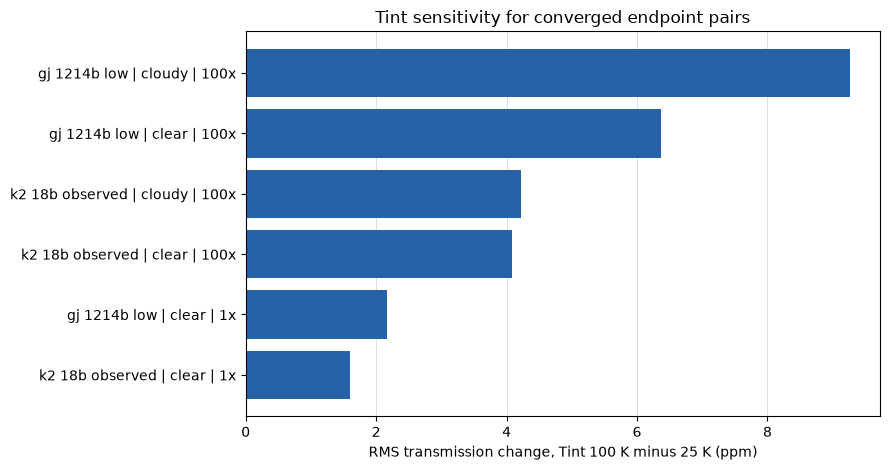

In [5]:
plot_rows = tint_pairs[tint_pairs.both_endpoints_converged].sort_values("rms_transmission_change_ppm")
fig, ax = plt.subplots(figsize=(9, 4.8))
ax.barh(plot_rows.pair_label, plot_rows.rms_transmission_change_ppm, color="#2563A6")
ax.set_xlabel("RMS transmission change, Tint 100 K minus 25 K (ppm)")
ax.set_title("Tint sensitivity for converged endpoint pairs")
ax.grid(axis="x", color="#D9DEE5", linewidth=0.7)
ax.set_axisbelow(True)
fig.tight_layout()
plt.show()

### 4. Compare gravity, metallicity, clouds, and the provisional hot case

In [6]:
case_summary = (
    models.groupby("case_id", as_index=False)
    .agg(
        valid_models=("run_index", "size"),
        converged_models=("climate_converged", "sum"),
        median_transmission_modulation_ppm=("transmission_modulation_ppm", "median"),
        minimum_transmission_modulation_ppm=("transmission_modulation_ppm", "min"),
        maximum_transmission_modulation_ppm=("transmission_modulation_ppm", "max"),
        median_temperature_1bar_k=("temperature_1bar_k", "median"),
    )
)
case_summary.to_csv(OUT / "case_summary.csv", index=False)
case_summary

,case_id,valid_models,converged_models,median_transmission_modulation_ppm,minimum_transmission_modulation_ppm,maximum_transmission_modulation_ppm,median_temperature_1bar_k
0,gj_1214b_low,12,9,172.324273,91.740848,190.658765,431.184673
1,gj_1214b_observed,2,2,394.697437,293.027455,496.367418,918.981676
2,k2_18b_observed,12,8,139.590857,76.141907,154.540503,438.599261


In [7]:
cloud_effects = models.pivot_table(
    index=["case_id", "tint_k", "metallicity_xsolar"],
    columns="cloud",
    values=["transmission_modulation_ppm", "visible_albedo_median", "climate_converged"],
    aggfunc="first",
).dropna()
cloud_effects["cloud_change_transmission_ppm"] = (
    cloud_effects[("transmission_modulation_ppm", "cloudy")]
    - cloud_effects[("transmission_modulation_ppm", "clear")]
)
cloud_effects["cloud_to_clear_albedo_ratio"] = (
    cloud_effects[("visible_albedo_median", "cloudy")]
    / cloud_effects[("visible_albedo_median", "clear")]
)
cloud_effects.reset_index().to_csv(OUT / "cloud_effects.csv", index=False)
cloud_effects[["cloud_change_transmission_ppm", "cloud_to_clear_albedo_ratio"]]

cloud_change_transmission_ppm  \
cloud                                                                     
case_id         tint_k metallicity_xsolar                                 
gj_1214b_low    25.0   1.0                                    -0.004766   
                       100.0                                 -60.196866   
                50.0   1.0                                    -0.015665   
                       100.0                                 -46.673656   
                100.0  1.0                                    -0.015209   
                       100.0                                 -61.627841   
k2_18b_observed 25.0   1.0                                    -0.010967   
                       100.0                                 -47.411553   
                50.0   1.0                                    -0.010813   
                       100.0                                 -47.390333   
                100.0  1.0                                    -0.010179   
                       100.0                                 -40.275071   

                                          cloud_to_clear_albedo_ratio  
cloud                                                                  
case_id         tint_k metallicity_xsolar                              
gj_1214b_low    25.0   1.0                                   1.000022  
                       100.0                                34.084394  
                50.0   1.0                                   1.000058  
                       100.0                                78.532011  
                100.0  1.0                                   1.000069  
                       100.0                                35.439513  
k2_18b_observed 25.0   1.0                                   1.000053  
                       100.0                                39.998908  
                50.0   1.0                                   1.000052  
                       100.0                                84.303942  
                100.0  1.0                                   1.000056  
                       100.0                                76.941848

### 5. Inventory failed attempts by root cause

In [8]:
failure_rows = []
for path in sorted(LOG_DIR.glob("*.err")):
    text = path.read_text(errors="replace")
    if "Traceback" not in text:
        continue
    if "missing required column 'kz'" in text:
        category = "Returned profile omitted kz"
        stage = "preflight"
    elif "transit_depth" in text and ("non-finite" in text or "finite native samples" in text):
        category = "Planet radius unavailable to transmission"
        stage = "preflight"
    elif "mixing across Pressure Ranges" in text:
        category = "Quench point below pressure grid"
        stage = "production"
    elif "particles would need to be smaller than gas atoms" in text:
        category = "Virga particle root below physical floor"
        stage = "corrected production"
    else:
        category = "Other"
        stage = "unknown"
    job_match = re.match(r"(?P<job>\d+)_(?P<index>\d+)\.err", path.name)
    failure_rows.append({
        "log_file": path.name,
        "job_id": int(job_match.group("job")) if job_match else None,
        "run_index": int(job_match.group("index")) if job_match else None,
        "stage": stage,
        "category": category,
    })

failures = pd.DataFrame(failure_rows)
failures.to_csv(OUT / "failure_inventory.csv", index=False)
failure_summary = (
    failures.groupby(["stage", "category"], as_index=False)
    .agg(failed_attempt_logs=("log_file", "size"), unique_run_indices=("run_index", "nunique"))
    .sort_values("failed_attempt_logs", ascending=False)
)
failure_summary.to_csv(OUT / "failure_summary.csv", index=False)
failure_summary

,stage,category,failed_attempt_logs,unique_run_indices
3,production,Quench point below pressure grid,12,12
1,preflight,Planet radius unavailable to transmission,10,9
0,corrected production,Virga particle root below physical floor,1,1
2,preflight,Returned profile omitted kz,1,1


## Limitations, uncertainty, and robustness checks

- The 500 K case is incomplete, so its two clear Tint=25 K points cannot establish Tint or cloud sensitivity.
- Seven files are finite and schema-valid but have `climate_converged=false`; they should not be used for final inference until convergence is improved or independently justified.
- Failed-attempt counts refer to traceback log files, not unique scientific models. Several models were retried during implementation diagnostics.
- Thermal planet/star ratios are excluded. The installed climate stellar path integrates stellar flux per native bin before dividing a planet flux density by it, producing a dimensional mismatch and implausibly large ratios.

## Takeaways

1. Tint is a secondary transmission driver in the two complete 255 K cases: converged 25→100 K endpoint differences span 1.6–9.3 ppm RMS.
2. Lower gravity increases the median transmission modulation: GJ 1214 b low is about 23% larger than K2-18 b across the complete grids.
3. At 100× solar, clouds suppress transmission modulation by roughly 40–62 ppm in the converged comparisons and raise visible geometric albedo by about 34–84×.
4. The current 500 K clear points show much larger modulation (293–496 ppm), but this is provisional until the remaining hot models finish and the thermal-ratio defect is corrected.